<h2>Que: Identify, visualize, and interpret outliers in the dataset using advanced boxplots, scatterplots, and distribution plots, followed by analyzing their potential impact on model performance and deciding on appropriate mitigation strategies.</h2>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")

In [6]:
sales = pd.read_csv(r'C:\Users\rutva\Downloads\DS AIML Projects\Daily tasks\Pharmacy management system\archive\sales.csv')
sales_item = pd.read_csv(r'C:\Users\rutva\Downloads\DS AIML Projects\Daily tasks\Pharmacy management system\archive\sales_item.csv')
suppliers = pd.read_csv(r'C:\Users\rutva\Downloads\DS AIML Projects\Daily tasks\Pharmacy management system\archive\suppliers.csv')
categories = pd.read_csv(r'C:\Users\rutva\Downloads\DS AIML Projects\Daily tasks\Pharmacy management system\archive\catrgories.csv')
customers = pd.read_csv(r'C:\Users\rutva\Downloads\DS AIML Projects\Daily tasks\Pharmacy management system\archive\customers.csv')
medicines = pd.read_csv(r'C:\Users\rutva\Downloads\DS AIML Projects\Daily tasks\Pharmacy management system\archive\medicines.csv')

In [9]:
medicines['purchase_price_num'] = pd.to_numeric(medicines['purchase_price'], errors='coerce')
medicines['selling_price_num'] = pd.to_numeric(medicines['selling_price'], errors='coerce')
medicines['mrp_num'] = pd.to_numeric(medicines['mrp'], errors='coerce')

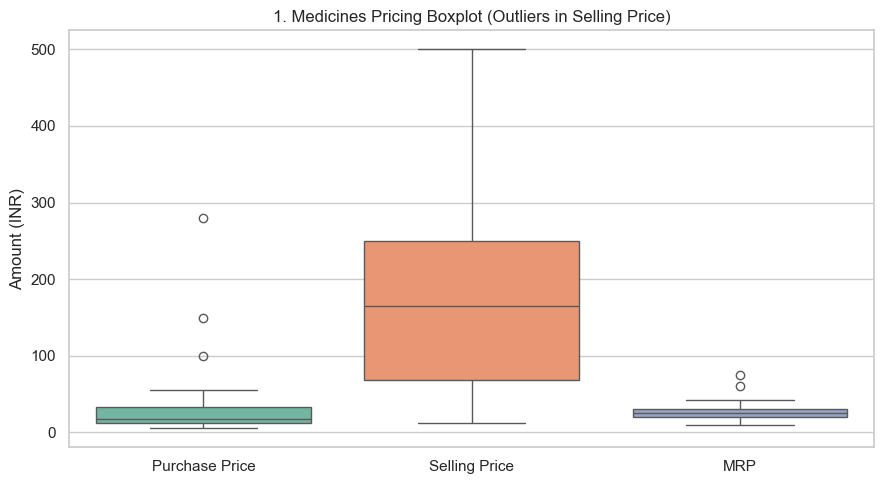

In [21]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=medicines[['purchase_price_num', 'selling_price_num', 'mrp_num']], palette="Set2")
plt.title("1. Medicines Pricing Boxplot (Outliers in Selling Price)")
plt.ylabel("Amount (INR)")
plt.xticks([0, 1, 2], ['Purchase Price', 'Selling Price', 'MRP'])
plt.tight_layout()
plt.show()

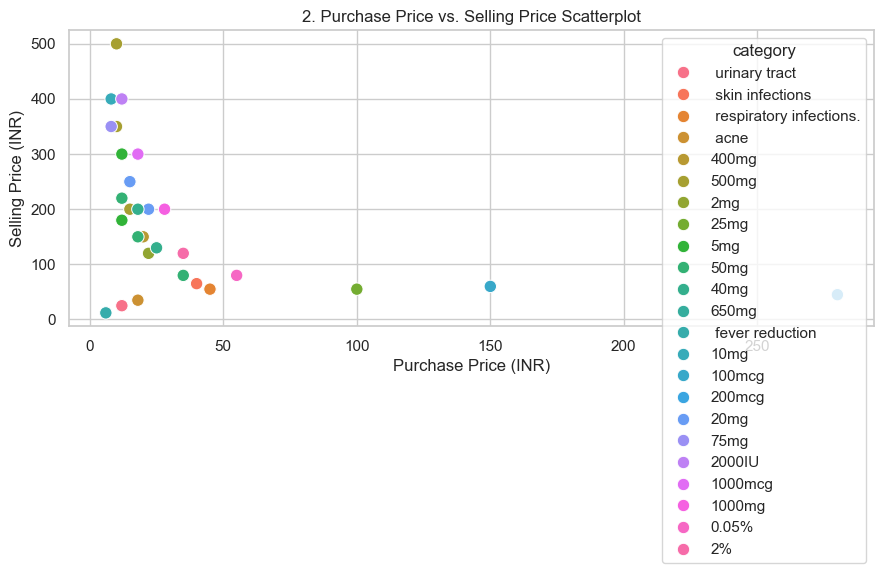

In [22]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=medicines, x='purchase_price_num', y='selling_price_num', hue='category', s=80)
plt.title("2. Purchase Price vs. Selling Price Scatterplot")
plt.xlabel("Purchase Price (INR)")
plt.ylabel("Selling Price (INR)")
plt.tight_layout()
plt.show()

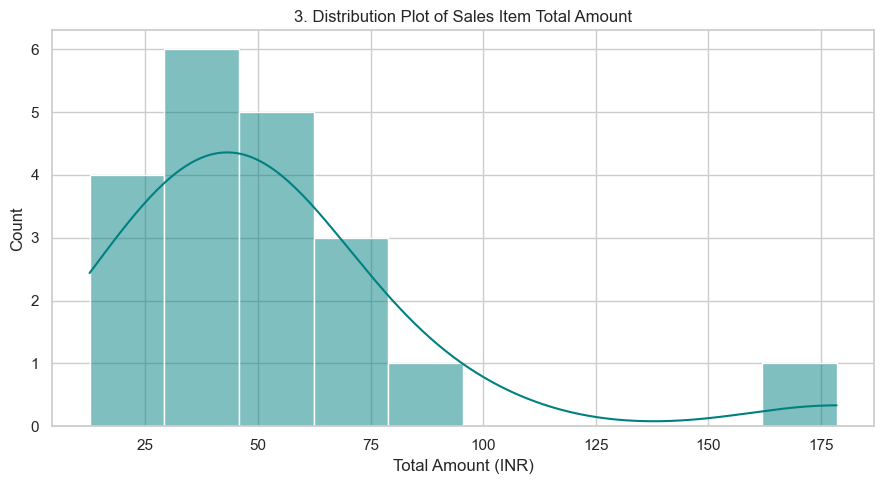

In [23]:
plt.figure(figsize=(9, 5))
sns.histplot(sales_item['total_amount'], kde=True, color='teal', bins=10)
plt.title("3. Distribution Plot of Sales Item Total Amount")
plt.xlabel("Total Amount (INR)")
plt.tight_layout()
plt.show()

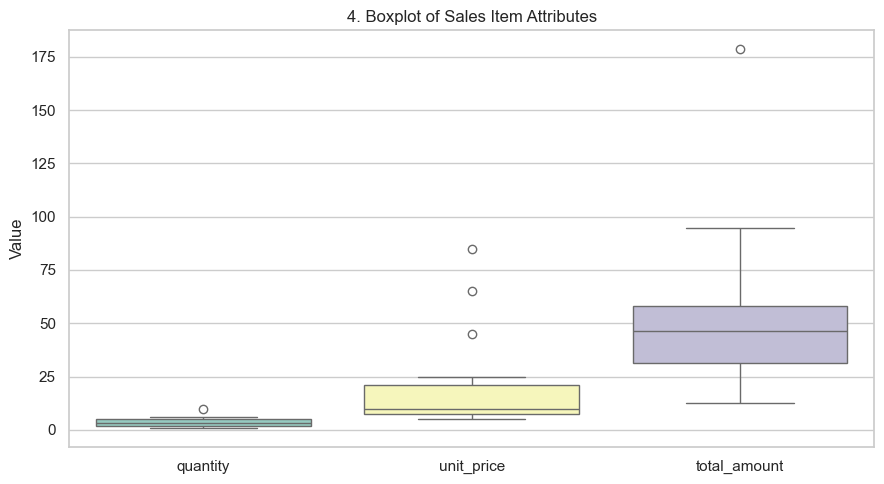

In [24]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=sales_item[['quantity', 'unit_price', 'total_amount']], palette="Set3")
plt.title("4. Boxplot of Sales Item Attributes")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

In [29]:
medicines['selling_price_cleaned'] = np.minimum(
    pd.to_numeric(medicines['selling_price'], errors='coerce'),
    pd.to_numeric(medicines['mrp'], errors='coerce')
)

In [30]:
medicines['current_stock_cleaned'] = pd.to_numeric(medicines['current_stock'], errors='coerce')
medicines['current_stock_cleaned'] = medicines['current_stock_cleaned'].fillna(
    medicines['current_stock_cleaned'].median()
)

In [31]:
upper_limit = sales_item['total_amount'].quantile(0.95)
sales_item['total_amount_winsorized'] = sales_item['total_amount'].clip(upper=upper_limit)

In [32]:
medicines.to_csv('medicines_cleaned.csv', index=False)
sales_item.to_csv('sales_item_cleaned.csv', index=False)

In [33]:
print("Clean datasets exported successfully without any warnings!")

Clean datasets exported successfully without any warnings!
